In [1]:
from lib.models.regnetv3.modules import XBlockV3, Permute, PositionalEncoding
from lib.models.regnetv3.regnet_encoder import RegNetEncoder
from torch import nn
import torch
from lib.data.dataloading import load_nursing_5_class, load_raw
from lib.models import RegNetv3
from lib.config import RAW_DIR
from lib.modules import optimization_loop_xonly, optimization_loop_multi_class
from lib.utils import sample_regnet

In [79]:
class RegNetDAEv3(nn.Module):
    def __init__(
            self, 
            winsize=None, in_channels=3, stem_out_c=None, d=None, w=None, 
            g=1, p_dropout=0, 
            maskpct=0.15, 
            CONFIG=None
        ):
        super().__init__()
        if CONFIG:
            winsize = CONFIG['WINDOW_SIZE']
            stem_out_c = CONFIG['WIDTHI'][0]
            maskpct = CONFIG['MASKPCT']
            d = CONFIG['DEPTHI']
            w = CONFIG['WIDTHI']
            p_dropout = CONFIG['PDROPOUT']
        if not stem_out_c:
            stem_out_c = w[0]

        self.maskpct = maskpct

        # dont change the name of self.e
        # self.e = RegNetEncoder(winsize, in_channels, stem_out_c, d, w, g, p_dropout)
        self.fc = nn.Sequential(
            nn.Linear(winsize*3,winsize*3),
            nn.Dropout(0.9)
        )
        # self.decoder_skip = nn.Sequential(
        #     nn.Conv1d(w[-1], in_channels, kernel_size=1),
        #     nn.Upsample(size=winsize),
        # )
        # self.decoder = nn.Sequential()
        # winv = w[::-1] + [w[0]]
        # for i,width in enumerate(winv[:-1]):
        #     s = 2 if width < winv[i+1] else 1
        #     self.decoder.add_module(
        #         f"decoder-{i}_w{width}",
        #         nn.ConvTranspose1d(width, winv[i+1], kernel_size=3, stride=s, groups=g),
        #     )
        # self.decoder.add_module(
        #     "decoder-final",
        #     nn.Sequential(
        #         nn.Upsample(size=(winsize//2)),
        #         nn.ConvTranspose1d(w[0], in_channels, kernel_size=3, stride=2)
        #     )
        # )

        # print('latent dim:',self.e.latent_dim)
    def forward(self, x):
        # x = x / x.mean(dim=2, keepdim=True)
        mask = torch.rand(x.shape[0], 1, x.shape[2]) < self.maskpct
        mask = mask.expand(-1, 3, -1)
        x = x * ~mask.to(x.device)
        # x = self.e(x)
        # x = self.decoder(x) + self.decoder_skip(x)
        return self.fc(x.flatten(1)).view(x.shape[0],3,-1) + x

In [80]:
CONFIG = {
    'WINDOW_SIZE':2001,
    'WINDOW_STRIDE':2001 // 4,
    'NURSING_STRIDE': 2001,
    'BATCH_SIZE': 256,
    'LEARNING_RATE': 1e-3,
    'CLASS_LR': 3e-4,
    'ENC_LEARNING_RATE': 5e-5,
    'TEST_SIZE': 0.1,
    'NURSING_TEST_SIZE': 0.25,
    'DEVICE': 'cuda:1',
    'DEPTHI': [1],
    'WIDTHI': [64],
    'MASKPCT': 0.0,
    'PDROPOUT': 0.0
}

# while True:
#     d,w,_ = sample_regnet()
#     CONFIG['DEPTHI'] = d
#     CONFIG['WIDTHI'] = w
#     nparams = sum([p.numel() for p in RegNetDAEv3(CONFIG=CONFIG).parameters()])
#     if nparams > 3_000_000 and nparams < 7_000_000:
#         print(nparams, d, w)
#         break

trainloader, testloader = load_raw(
    RAW_DIR,
    CONFIG['WINDOW_SIZE'],
    test_size=CONFIG['TEST_SIZE'],
    batch_size=CONFIG['BATCH_SIZE'],
    shuffle_test=True,
    chunk_len_hrs=0.25,
    stride=CONFIG['WINDOW_STRIDE']
)
len(trainloader.dataset), len(testloader.dataset)

model = RegNetDAEv3(CONFIG=CONFIG).to(CONFIG['DEVICE'])
# criterion = nn.MSELoss()
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG['LEARNING_RATE'])

outdir = f'dev/10_dae/mask0-fc-l1-do'
optimization_loop_xonly(
    model,
    trainloader,
    testloader,
    criterion,
    optimizer,
    epochs=100,
    patience=20,
    config=CONFIG,
    continue_training=False,
    device=CONFIG['DEVICE'],
    outdir=outdir,
    writer=outdir,
)

Using all available sessions
Using Directories: ['2022-12-20_15_10_43.pt', '10-28_13_18_42.pt', '2022-12-10_14_27_45.pt', '2023-11-11_17_50_20.pt', '2022-12-20_11_18_54.pt', '2022-12-08_14_30_54.pt', '2023-11-01_15_49_48.pt', '2022-12-20_10_54_30.pt', '2023-10-26_15_32_20.pt', '2022-12-12_07_03_40.pt', '11-07_17_43_30.pt', '2023-02-11_13_51_34.pt', '11-07_12_58_43.pt', '2024-02-27_09_39_32.pt', '2023-11-02_13_55_22.pt', '2023-11-10_13_11_41.pt', '10-27_00_21_25.pt', '2022-12-21_14_16_02.pt', '2022-12-10_12_57_32.pt', '2018-01-01_13_33_47.pt', '11-07_15_03_24.pt', '11-07_17_29_01.pt', '11-08_08_27_30.pt', '2022-12-19_08_37_36.pt', '2022-12-06_17_27_56.pt', '2018-01-02_18_25_12.pt', '2022-12-06_15_48_49.pt', '11-01_20_34_28.pt', '2022-12-06_18_21_08.pt', '10-27_09_45_42.pt', '2023-11-01_15_47_52.pt', '2024-02-22_18_21_48.pt', '2022-12-08_11_52_09.pt', '2018-01-03_13_28_35.pt', '11-08_07_17_47.pt', '2022-12-08_19_04_00.pt', '11-02_19_28_19.pt', '2024-03-17_13_08_04.pt', '11-10_08_54_24.pt

: Epoch 8: Train Loss: 2.0982: Dev Loss: 2.17:   9%|▉         | 9/100 [00:52<08:43,  5.76s/it]  

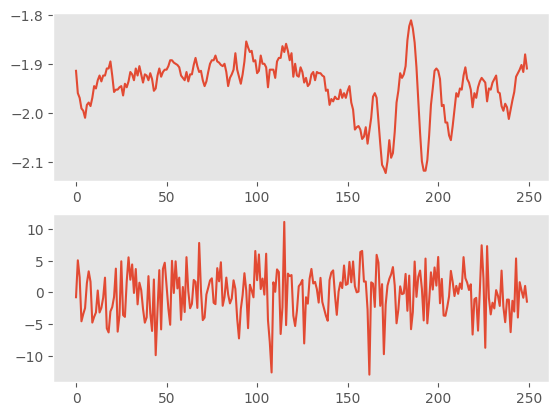

In [54]:
import matplotlib.pyplot as plt
CONFIG = {
    'WINDOW_SIZE':2001,
    'WINDOW_STRIDE':2001,
    'NURSING_STRIDE': 2001 // 16,
    'BATCH_SIZE': 256,
    'LEARNING_RATE': 1e-3,
    'CLASS_LR': 3e-4,
    'ENC_LEARNING_RATE': 5e-5,
    'TEST_SIZE': 0.1,
    'NURSING_TEST_SIZE': 0.25,
    'DEVICE': 'cuda:1',
    'DEPTHI': [1],
    'WIDTHI': [64],
    'MASKPCT': 0.0,
    'PDROPOUT': 0.0
}
model = RegNetDAEv3(CONFIG=CONFIG)
X = next(iter(trainloader))
x = model(X)
fig, axes = plt.subplots(2)
axes[0].plot(X[4,0,:250].detach().cpu().numpy())
axes[1].plot(x[4,0,:250].detach().cpu().numpy())
for ax in axes:
    ax.grid()

In [32]:
import pandas as pd
import plotly.express as px
X = next(iter(testloader))
logits = model(X.to(CONFIG['DEVICE'])).detach().cpu().numpy()
i = slice(0,10)
df = pd.DataFrame({
    'x': X[i,0].flatten(), 
    'y': X[i,1].flatten(), 
    'z': X[i,2].flatten(), 
    'x_pred': logits[i,0].flatten(), 
    'y_pred': logits[i,1].flatten(), 
    'z_pred': logits[i,2].flatten()
})
fig = px.line(df, x=df.index, y=['x', 'x_pred', 'y', 'y_pred', 'z', 'z_pred'])
fig.show(renderer='browser')